# Notebook 03 — Model Evaluation
**FracAtlas YOLOv8s Fracture Detection Pipeline**

Evaluates the trained model on the held-out test set and generates all required
visualisations for scientific publication.


## 0. Imports

In [1]:
# Enable inline plotting for Jupyter notebooks
%matplotlib inline

import os, json, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from tqdm import tqdm

# Configure matplotlib to display figures inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

SAVE_DPI = 150
OUTPUT_FIGS = Path(".")  # Save evaluation figures to project root
print("Libraries loaded")
print("Figures will be displayed inline and saved to:", OUTPUT_FIGS.absolute())


Libraries loaded
Figures will be displayed inline and saved to: D:\Project Medical Object Detection\FracAtlas\notebooks


## 1. Paths & Model

In [2]:
from pathlib import Path

# Set path absolut ke folder utama proyek
BASE_DIR   = Path(r"D:\Project Medical Object Detection\FracAtlas")
RUNS_DIR   = BASE_DIR / "runs" / "detect"
RUN_NAME   = "fracatlas_yolov8s local"
YAML_PATH  = BASE_DIR / "fracatlas_hand_oversampled.yaml"
BEST_MODEL = RUNS_DIR / RUN_NAME / "weights" / "best.pt"

assert BEST_MODEL.exists(), f"❌ best.pt not found: {BEST_MODEL}\nRun Notebook 02 first."

model = YOLO(str(BEST_MODEL))
print(f"Loaded model: {BEST_MODEL}")

with open(YAML_PATH) as f:
    data_cfg = yaml.safe_load(f)

dataset_path = Path(data_cfg["path"])
test_img_dir = dataset_path / "test" / "images"
test_lbl_dir = dataset_path / "test" / "labels"
print(f"Test images: {len(list(test_img_dir.iterdir()))}")


Loaded model: D:\Project Medical Object Detection\FracAtlas\runs\detect\fracatlas_yolov8s local\weights\best.pt
Test images: 231


## 2. Run Ultralytics Built-in Validation (mAP, P, R, F1)

In [3]:
# Official YOLO validation on the test split
val_results = model.val(
    data      = str(YAML_PATH),
    split     = "test",
    imgsz     = 640,
    conf      = 0.001,        # Standard: 0.001 untuk mAP calculation yang benar
    iou       = 0.5,
    augment   = True,         # TTA: Test-Time Augmentation
    plots     = True,
    save_json = False,
    project   = str(RUNS_DIR),
    name      = RUN_NAME + "_eval",
    exist_ok  = True,
)

# Extract metrics
mp      = float(val_results.results_dict.get("metrics/precision(B)", 0))
mr      = float(val_results.results_dict.get("metrics/recall(B)", 0))
map50   = float(val_results.results_dict.get("metrics/mAP50(B)", 0))
map5095 = float(val_results.results_dict.get("metrics/mAP50-95(B)", 0))
f1_val  = 2 * mp * mr / (mp + mr) if (mp + mr) > 0 else 0

print("\n" + "="*50)
print("  TEST SET PERFORMANCE METRICS")
print("="*50)
print(f"  Precision  : {mp:.4f}")
print(f"  Recall     : {mr:.4f}")
print(f"  F1-Score   : {f1_val:.4f}")
print(f"  mAP@50     : {map50:.4f}")
print(f"  mAP@50-95  : {map5095:.4f}")
print("="*50)


Ultralytics 8.4.21  Python-3.10.6 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


val: Fast image access  (ping: 0.10.0 ms, read: 85.07.9 MB/s, size: 14.7 KB)


val: Scanning D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_oversampled\test\labels... 197 images, 138 backgrounds, 0 corrupt: 85% ━━━━━━━━━━── 197/231 589.6it/s 0.1s<0.1s

val: Scanning D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_oversampled\test\labels... 225 images, 159 backgrounds, 6 corrupt: 100% ━━━━━━━━━━━━ 231/231 1.9Kit/s 0.1s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.8it/s 8.2s

                   all        225         85      0.967      0.941      0.977      0.518


Speed: 7.0ms preprocess, 24.7ms inference, 0.0ms loss, 0.9ms postprocess per image


Results saved to D:\Project Medical Object Detection\FracAtlas\runs\detect\fracatlas_yolov8s local_eval



  TEST SET PERFORMANCE METRICS
  Precision  : 0.9675
  Recall     : 0.9412
  F1-Score   : 0.9541
  mAP@50     : 0.9772
  mAP@50-95  : 0.5181


## 3. Collect Raw Predictions for Custom Curves

In [4]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Run predictions at low confidence to collect scores for PR / F1 curves
all_scores, all_labels_gt = [], []

test_images = sorted(test_img_dir.iterdir())

for img_path in tqdm(test_images, desc="Predicting"):
    lbl_path = test_lbl_dir / (img_path.stem + ".txt")
    gt_lines = lbl_path.read_text().strip().splitlines() if lbl_path.exists() else []
    gt_boxes = len([l for l in gt_lines if l.strip()])

    with Image.open(img_path) as pil_img:
        pil_img = pil_img.convert("RGB")
        preds = model.predict(pil_img, conf=0.01, iou=0.5, verbose=False)
    boxes = preds[0].boxes if preds else None

    if boxes is not None and len(boxes) > 0:
        scores = boxes.conf.cpu().numpy()
    else:
        scores = np.array([])

    # Image-level: any GT box => positive; any pred => score
    img_gt = 1 if gt_boxes > 0 else 0
    if len(scores) > 0:
        all_scores.append(float(scores.max()))
    else:
        all_scores.append(0.0)
    all_labels_gt.append(img_gt)

all_scores   = np.array(all_scores)
all_labels_gt = np.array(all_labels_gt)
print(f"\nTotal test images : {len(all_labels_gt)}")
print(f"Positives (frac.) : {all_labels_gt.sum()}")
print(f"Negatives         : {(all_labels_gt==0).sum()}")


Predicting:   0%|          | 0/231 [00:00<?, ?it/s]

Predicting:   0%|          | 1/231 [00:00<00:46,  4.90it/s]

Predicting:   1%|          | 2/231 [00:00<00:41,  5.46it/s]

Predicting:   1%|▏         | 3/231 [00:00<00:35,  6.47it/s]

Predicting:   2%|▏         | 4/231 [00:00<00:33,  6.70it/s]

...

Predicting:  95%|█████████▌| 220/231 [00:07<00:00, 43.53it/s]

Predicting:  97%|█████████▋| 225/231 [00:07<00:00, 40.60it/s]

Predicting: 100%|█████████▉| 230/231 [00:07<00:00, 41.96it/s]

Predicting: 100%|██████████| 231/231 [00:07<00:00, 29.39it/s]


Total test images : 231
Positives (frac.) : 66
Negatives         : 165


## 4. Precision–Recall Curve

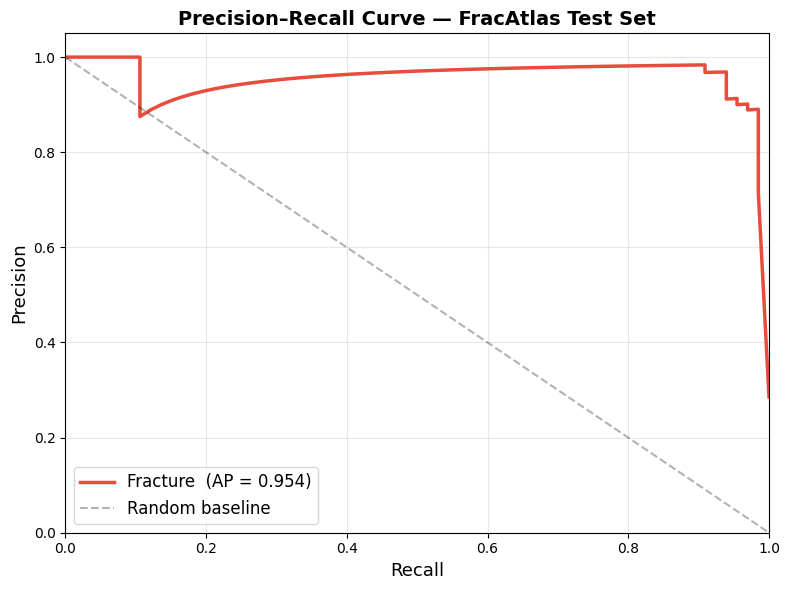

Saved & displayed precision_recall_curve.png  |  AP=0.9538


In [5]:
precision_arr, recall_arr, pr_thresholds = precision_recall_curve(all_labels_gt, all_scores)
ap = average_precision_score(all_labels_gt, all_scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_arr, precision_arr, color="#e74c3c", linewidth=2.5,
        label=f"Fracture  (AP = {ap:.3f})")
ax.plot([0, 1], [1, 0], "k--", alpha=0.3, label="Random baseline")
ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision–Recall Curve — FracAtlas Test Set", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "precision_recall_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print(f"Saved & displayed precision_recall_curve.png  |  AP={ap:.4f}")


## 5. Confusion Matrix

Box-level CM:   0%|          | 0/231 [00:00<?, ?it/s]

Box-level CM:   1%|          | 2/231 [00:00<00:16, 13.63it/s]

Box-level CM:   2%|▏         | 4/231 [00:00<00:21, 10.76it/s]

Box-level CM:   3%|▎         | 6/231 [00:00<00:22,  9.82it/s]

Box-level CM:   3%|▎         | 8/231 [00:00<00:25,  8.76it/s]

...

Box-level CM:  93%|█████████▎| 215/231 [00:09<00:00, 57.26it/s]

Box-level CM:  96%|█████████▌| 221/231 [00:09<00:00, 57.22it/s]

Box-level CM:  98%|█████████▊| 227/231 [00:09<00:00, 56.50it/s]

Box-level CM: 100%|██████████| 231/231 [00:09<00:00, 24.67it/s]

TP=83  FP=133  FN=2  TN(bg images)=100
Precision : 0.3843
Recall    : 0.9765


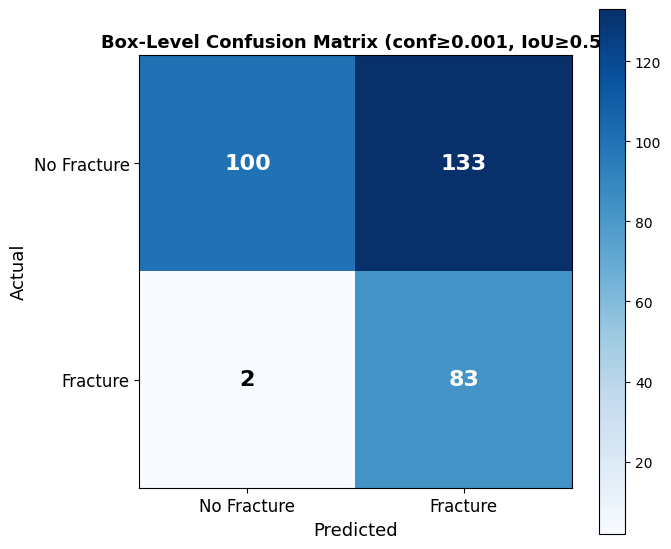

✅ Saved confusion_matrix.png (box-level)


In [6]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ─── Box-Level Confusion Matrix ────────────────────────────────────────────
# Setiap predicted box dievaluasi terhadap GT box via IoU >= IOU_THRESH.
# Ini lebih tepat untuk object detection daripada image-level binary.
CONF_THRESH = 0.001   # sama seperti sebelumnya
IOU_THRESH  = 0.50

def _iou(b1, b2):
    xA, yA = max(b1[0],b2[0]), max(b1[1],b2[1])
    xB, yB = min(b1[2],b2[2]), min(b1[3],b2[3])
    inter = max(0,xB-xA)*max(0,yB-yA)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    u = a1+a2-inter
    return inter/u if u>0 else 0.0

tp_b = fp_b = fn_b = tn_b = 0

for img_path in tqdm(sorted(test_img_dir.iterdir()), desc="Box-level CM"):
    lbl_path = test_lbl_dir / (img_path.stem + ".txt")
    with Image.open(img_path) as _img:
        _img = _img.convert("RGB")
        iw, ih = _img.size
        preds = model.predict(_img, conf=CONF_THRESH, iou=0.5, verbose=False)

    gt_boxes = []
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            if not line.strip(): continue
            p = list(map(float, line.strip().split()))
            xc,yc,w,h = p[1:5]
            gt_boxes.append([(xc-w/2)*iw,(yc-h/2)*ih,(xc+w/2)*iw,(yc+h/2)*ih])

    pred_boxes = []
    if preds and preds[0].boxes is not None and len(preds[0].boxes)>0:
        pred_boxes = [preds[0].boxes.xyxy[i].tolist() for i in range(len(preds[0].boxes))]

    if not gt_boxes and not pred_boxes:
        tn_b += 1          # background image, no false alarm
        continue
    if not gt_boxes:       # background image with false alarms
        fp_b += len(pred_boxes); continue
    if not pred_boxes:     # positive image, all GT missed
        fn_b += len(gt_boxes); continue

    matched = set()
    for pb in pred_boxes:
        best_iou, best_j = 0.0, -1
        for j, gb in enumerate(gt_boxes):
            if j in matched: continue
            v = _iou(pb, gb)
            if v > best_iou: best_iou, best_j = v, j
        if best_iou >= IOU_THRESH and best_j >= 0:
            tp_b += 1; matched.add(best_j)
        else:
            fp_b += 1
    fn_b += len(gt_boxes) - len(matched)

print(f"TP={tp_b}  FP={fp_b}  FN={fn_b}  TN(bg images)={tn_b}")
print(f"Precision : {tp_b/max(tp_b+fp_b,1):.4f}")
print(f"Recall    : {tp_b/max(tp_b+fn_b,1):.4f}")

# ─── Plot ───────────────────────────────────────────────────────────────────
import numpy as np
cm_arr = np.array([[tn_b, fp_b],
                   [fn_b, tp_b]], dtype=int)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_arr, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
classes = ['No Fracture', 'Fracture']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=12)
ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=12)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Box-Level Confusion Matrix (conf≥{CONF_THRESH}, IoU≥{IOU_THRESH})',
             fontsize=13, fontweight='bold')
thresh = cm_arr.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_arr[i,j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm_arr[i,j]>thresh else 'black')
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / 'confusion_matrix_yolov8s.png', dpi=SAVE_DPI)
plt.show()
print('\u2705 Saved confusion_matrix.png (box-level)')


## 6. F1-Score vs Confidence Threshold Curve

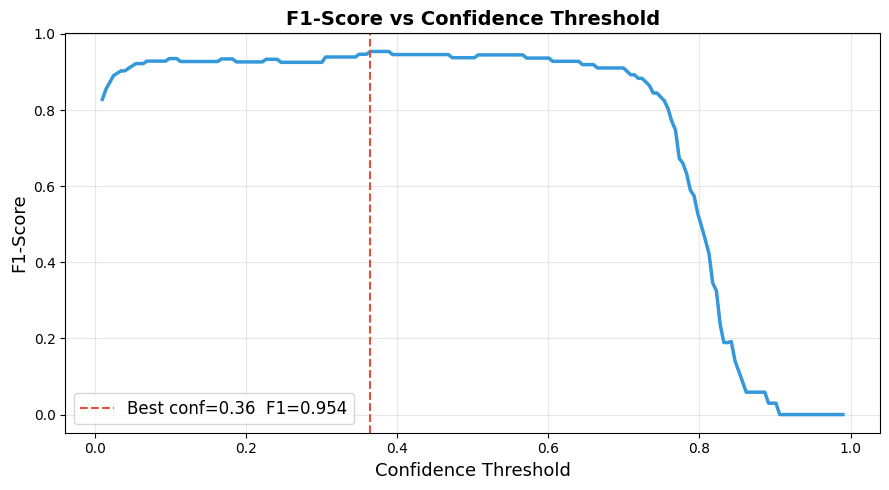

Saved & displayed f1_curve.png  |  Best F1=0.9538 @ conf=0.36


In [7]:
thresholds_list = np.linspace(0.01, 0.99, 200)
f1_scores_list  = []

for t in thresholds_list:
    preds_t = (all_scores >= t).astype(int)
    f1 = f1_score(all_labels_gt, preds_t, zero_division=0)
    f1_scores_list.append(f1)

best_idx = np.argmax(f1_scores_list)
best_conf = thresholds_list[best_idx]
best_f1   = f1_scores_list[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_list, f1_scores_list, color="#3498db", linewidth=2.5)
ax.axvline(best_conf, color="#e74c3c", linestyle="--", label=f"Best conf={best_conf:.2f}  F1={best_f1:.3f}")
ax.set_xlabel("Confidence Threshold", fontsize=13)
ax.set_ylabel("F1-Score", fontsize=13)
ax.set_title("F1-Score vs Confidence Threshold", fontsize=14, fontweight="bold")
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "f1_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print(f"Saved & displayed f1_curve.png  |  Best F1={best_f1:.4f} @ conf={best_conf:.2f}")


## 7. Precision Curve

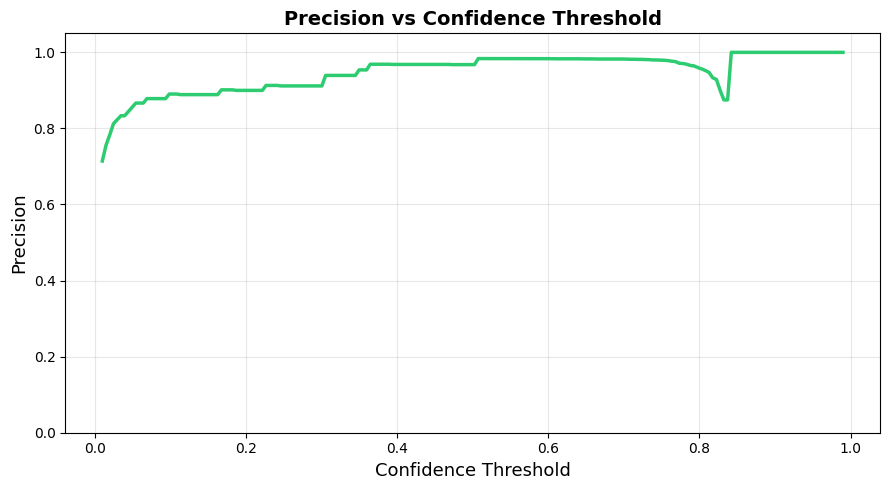

Saved & displayed precision_curve.png


In [8]:
prec_list = []
for t in thresholds_list:
    preds_t = (all_scores >= t).astype(int)
    tp_ = ((preds_t == 1) & (all_labels_gt == 1)).sum()
    fp_ = ((preds_t == 1) & (all_labels_gt == 0)).sum()
    prec_list.append(tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 1.0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_list, prec_list, color="#2ecc71", linewidth=2.5)
ax.set_xlabel("Confidence Threshold", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision vs Confidence Threshold", fontsize=14, fontweight="bold")
ax.set_ylim([0, 1.05]); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "precision_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print("Saved & displayed precision_curve.png")


## 8. Recall Curve

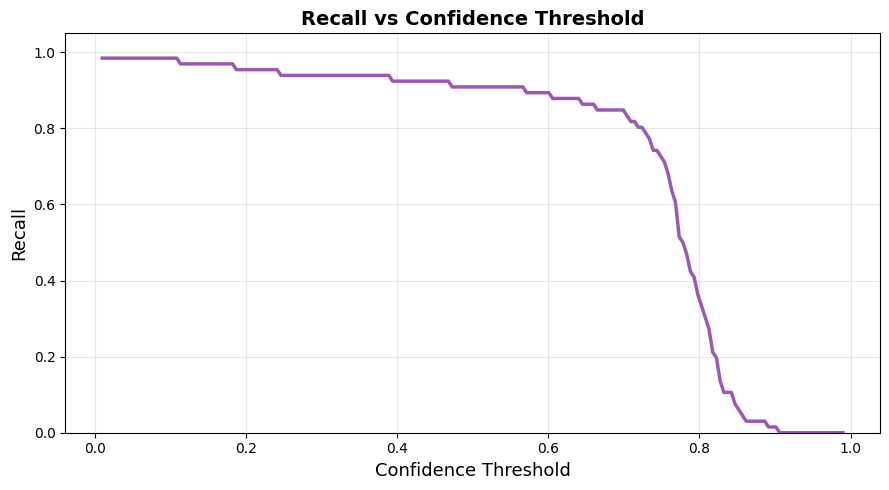

Saved & displayed recall_curve.png


In [9]:
rec_list = []
for t in thresholds_list:
    preds_t = (all_scores >= t).astype(int)
    tp_ = ((preds_t == 1) & (all_labels_gt == 1)).sum()
    fn_ = ((preds_t == 0) & (all_labels_gt == 1)).sum()
    rec_list.append(tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_list, rec_list, color="#9b59b6", linewidth=2.5)
ax.set_xlabel("Confidence Threshold", fontsize=13)
ax.set_ylabel("Recall", fontsize=13)
ax.set_title("Recall vs Confidence Threshold", fontsize=14, fontweight="bold")
ax.set_ylim([0, 1.05]); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "recall_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print("Saved & displayed recall_curve.png")


## 9. mAP Curve (across IoU thresholds)

Computing mAP across IoU thresholds...


  0%|          | 0/10 [00:00<?, ?it/s]

Ultralytics 8.4.21  Python-3.10.6 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


val: Fast image access  (ping: 0.10.0 ms, read: 119.79.9 MB/s, size: 14.9 KB)


val: Scanning D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_oversampled\test\labels.cache... 225 images, 159 backgrounds, 6 corrupt: 100% ━━━━━━━━━━━━ 231/231  0.0s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.0it/s 7.4s

                   all        225         85      0.483      0.259      0.298      0.145


Speed: 4.0ms preprocess, 24.2ms inference, 0.0ms loss, 1.1ms postprocess per image


100%|██████████| 10/10 [05:24<00:00, 32.40s/it]

100%|██████████| 10/10 [05:24<00:00, 32.41s/it]

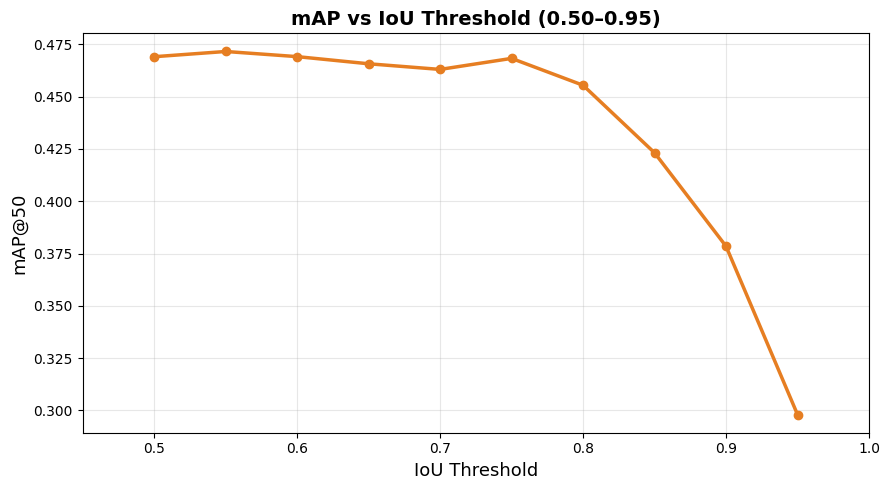

Saved & displayed map_curve.png


In [10]:
# Approximate mAP across IoU thresholds by running val at different IoU values
iou_thresholds = np.arange(0.50, 1.00, 0.05)
map_per_iou    = []

print("Computing mAP across IoU thresholds...")
for iou_t in tqdm(iou_thresholds):
    r = model.val(data=str(YAML_PATH), split="test", imgsz=1024,
                  conf=0.001, iou=float(iou_t), verbose=False, plots=False,
                  project=str(RUNS_DIR), name="_tmp_iou", exist_ok=True)
    map50_t = float(r.results_dict.get("metrics/mAP50(B)", 0))
    map_per_iou.append(map50_t)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(iou_thresholds, map_per_iou, "o-", color="#e67e22", linewidth=2.5, markersize=6)
ax.set_xlabel("IoU Threshold", fontsize=13)
ax.set_ylabel("mAP@50", fontsize=13)
ax.set_title("mAP vs IoU Threshold (0.50–0.95)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_xlim([0.45, 1.0])
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "map_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print("Saved & displayed map_curve.png")


## 10. Training Metrics Graph

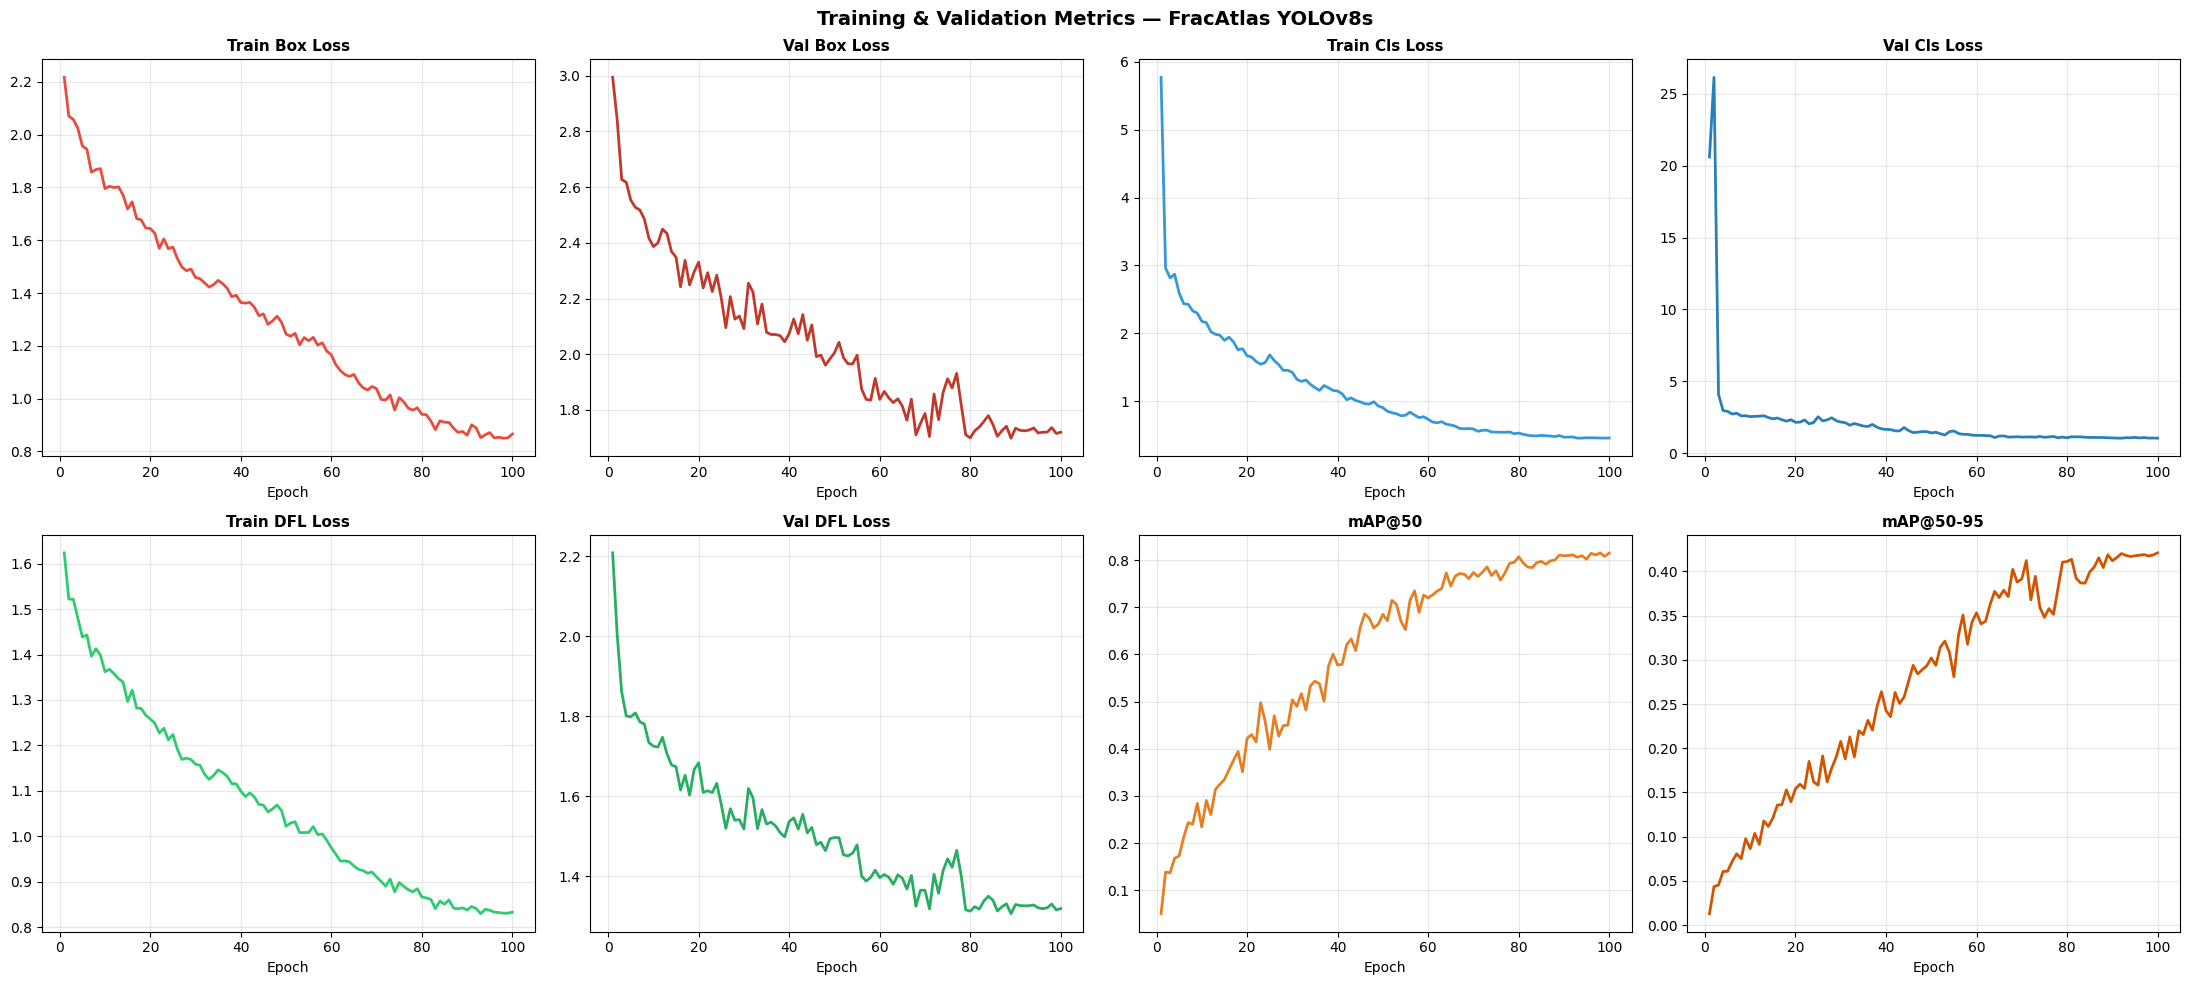

Saved & displayed training_metrics.png


In [11]:
results_csv = RUNS_DIR / RUN_NAME / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()

    cols_to_plot = [
        ("train/box_loss",      "Train Box Loss",    "#e74c3c"),
        ("val/box_loss",        "Val Box Loss",      "#c0392b"),
        ("train/cls_loss",      "Train Cls Loss",    "#3498db"),
        ("val/cls_loss",        "Val Cls Loss",      "#2980b9"),
        ("train/dfl_loss",      "Train DFL Loss",    "#2ecc71"),
        ("val/dfl_loss",        "Val DFL Loss",      "#27ae60"),
        ("metrics/mAP50(B)",    "mAP@50",            "#e67e22"),
        ("metrics/mAP50-95(B)", "mAP@50-95",         "#d35400"),
    ]

    for ax, (col, title, color) in zip(axes, cols_to_plot):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], color=color, linewidth=2)
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(title, fontsize=11)

    plt.suptitle("Training & Validation Metrics — FracAtlas YOLOv8s",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGS / "training_metrics.png", dpi=SAVE_DPI)
    plt.show()  # Display the figure inline
    print("Saved & displayed training_metrics.png")
else:
    print(f"{results_csv} not found. Run Notebook 02 first.")


## 11. Summary Table

In [12]:
summary = {
    "Metric": ["Precision", "Recall", "F1-Score", "mAP@50", "mAP@50-95",
               "Best F1 Threshold", "Average Precision (PR)"],
    "Value":  [f"{mp:.4f}", f"{mr:.4f}", f"{f1_val:.4f}",
               f"{map50:.4f}", f"{map5095:.4f}",
               f"{best_conf:.2f}", f"{ap:.4f}"],
}
df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# Save as CSV
df_summary.to_csv(OUTPUT_FIGS / "evaluation_summary.csv", index=False)
print("\n✅ Saved evaluation_summary.csv")
print("\n📝 Saved evaluation figures:")
for f in ["precision_recall_curve.png", "confusion_matrix.png", "map_curve.png",
          "f1_curve.png", "precision_curve.png", "recall_curve.png", "training_metrics.png"]:
    exists = (OUTPUT_FIGS / f).exists()
    print(f"   {'✅' if exists else '❌'} {f}")


                Metric  Value
             Precision 0.9675
                Recall 0.9412
              F1-Score 0.9541
                mAP@50 0.9772
             mAP@50-95 0.5181
     Best F1 Threshold   0.36
Average Precision (PR) 0.9538

✅ Saved evaluation_summary.csv

📝 Saved evaluation figures:
   ✅ precision_recall_curve.png
   ❌ confusion_matrix.png
   ✅ map_curve.png
   ✅ f1_curve.png
   ✅ precision_curve.png
   ✅ recall_curve.png
   ✅ training_metrics.png
